#***DAE Group Project***
*A Statistical Approach with RCBD & Factorial Design*



##***Data Overview***

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Load the dataset
file_path = "/content/big4_financial_risk_compliance.csv"
df = pd.read_csv(file_path)

In [25]:
# Dataset Overview
print("Dataset Overview:")
print(df.head())
print(df.info())
print(df.describe())

Dataset Overview:
   Year Firm_Name  Total_Audit_Engagements  High_Risk_Cases  \
0  2020       PwC                     2829               51   
1  2022  Deloitte                     3589              185   
2  2020       PwC                     2438              212   
3  2021       PwC                     2646              397   
4  2020       PwC                     2680              216   

   Compliance_Violations  Fraud_Cases_Detected Industry_Affected  \
0                    123                    39        Healthcare   
1                     30                    60        Healthcare   
2                    124                    97        Healthcare   
3                     55                    97        Healthcare   
4                     99                    46        Healthcare   

   Total_Revenue_Impact AI_Used_for_Auditing  Employee_Workload  \
0                114.24                   No                 57   
1                156.98                  Yes                

## ***Data Visualization***

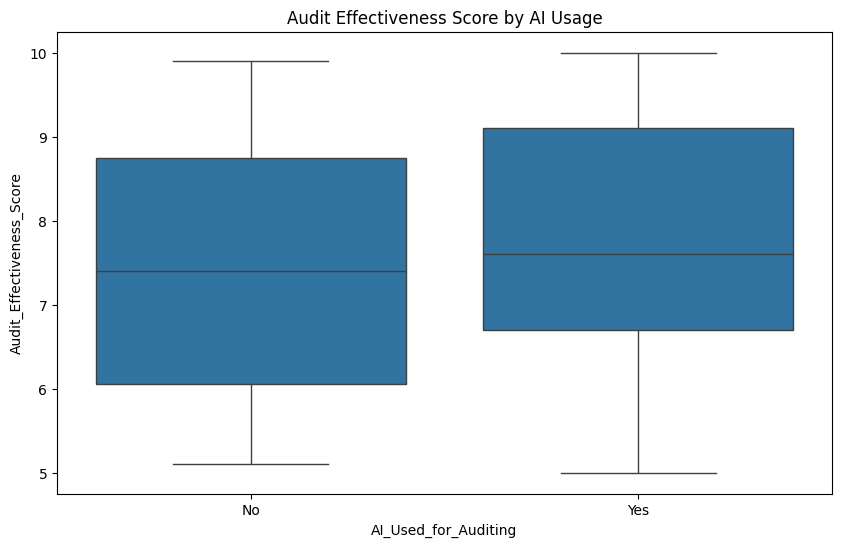

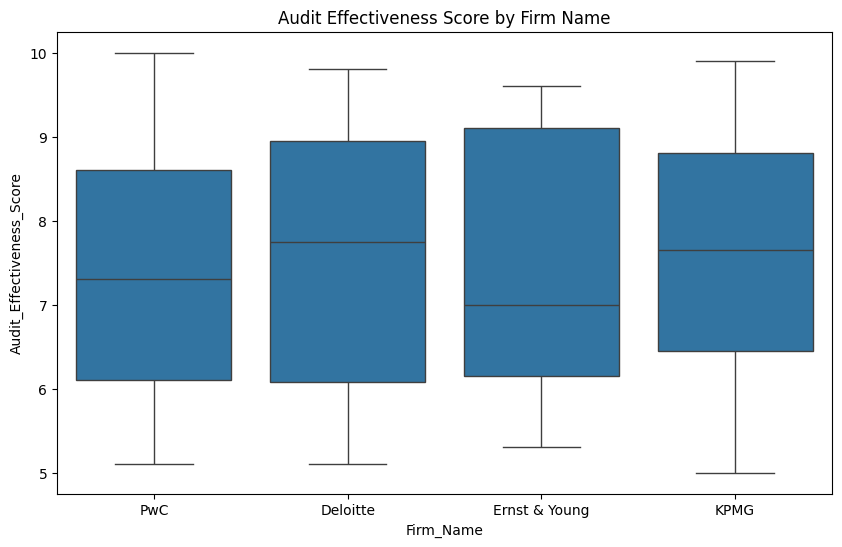

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='AI_Used_for_Auditing', y='Audit_Effectiveness_Score', data=df)
plt.title('Audit Effectiveness Score by AI Usage')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Firm_Name', y='Audit_Effectiveness_Score', data=df)
plt.title('Audit Effectiveness Score by Firm Name')
plt.show()

## ***Randomized Complete Block Design (RCBD)***

<ipython-input-27-18dc78e74e2b>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rcbd['AI_Used_for_Auditing'] = df_rcbd['AI_Used_for_Auditing'].map({'Yes': 1, 'No': 0})


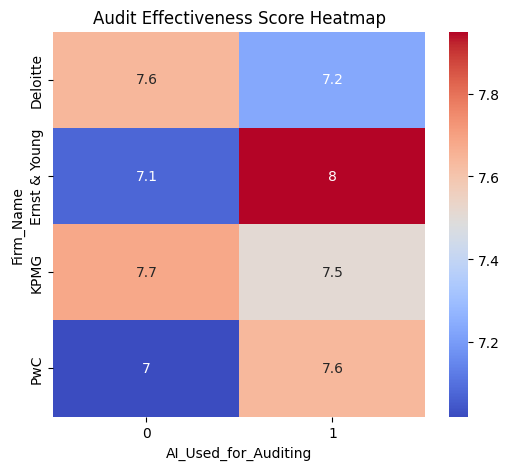

In [27]:
# Factor: AI_Used_for_Auditing (Yes/No)
# Blocking Factor: Firm_Name (EY, PwC, Deloitte, KPMG)
# Response Variable: Audit_Effectiveness_Score

# Filtering necessary columns
df_rcbd = df[['Firm_Name', 'AI_Used_for_Auditing', 'Audit_Effectiveness_Score']]

# Convert categorical variables to numerical format
df_rcbd['AI_Used_for_Auditing'] = df_rcbd['AI_Used_for_Auditing'].map({'Yes': 1, 'No': 0})

# Heatmap of Audit Effectiveness Score by Firm & AI Usage
heatmap_data = df_rcbd.pivot_table(values="Audit_Effectiveness_Score", index="Firm_Name", columns="AI_Used_for_Auditing")
plt.figure(figsize=(6,5))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm")
plt.title("Audit Effectiveness Score Heatmap")
plt.show()

In [28]:
# Compute means
grand_mean = df_rcbd['Audit_Effectiveness_Score'].mean()
factor_means = df_rcbd.groupby('AI_Used_for_Auditing')['Audit_Effectiveness_Score'].mean()
block_means = df_rcbd.groupby('Firm_Name')['Audit_Effectiveness_Score'].mean()

# Compute Sum of Squares (SS)
SS_total = ((df_rcbd['Audit_Effectiveness_Score'] - grand_mean) ** 2).sum()
SS_factor = sum(df_rcbd.groupby('AI_Used_for_Auditing').size() * (factor_means - grand_mean) ** 2)
SS_block = sum(df_rcbd.groupby('Firm_Name').size() * (block_means - grand_mean) ** 2)
SS_error = SS_total - SS_factor - SS_block

# Compute Degrees of Freedom (DOF)
df_factor = len(factor_means) - 1
df_block = len(block_means) - 1
df_error = len(df_rcbd) - (df_factor + df_block + 1)

# Compute Mean Squares and F-statistics (MS)
MS_factor = SS_factor / df_factor
MS_block = SS_block / df_block
MS_error = SS_error / df_error
F_factor = MS_factor / MS_error

In [29]:
from scipy.stats import f
from tabulate import tabulate

# F-critical (α = 0.05)
F_critical_rcbd = f.ppf(0.95, df_factor, df_error)
hypothesis_rcbd = "Rejected" if F_factor > F_critical_rcbd else "Accepted"

# RCBD ANOVA Table
rcbd_table = [
    ["AI Usage", SS_factor, df_factor, MS_factor, F_factor],
    ["Firm Name", SS_block, df_block, MS_block, ""],
    ["Error", SS_error, df_error, MS_error, ""],
    ["Total", SS_total, df_factor + df_block + df_error, "", ""]
]

print(tabulate(rcbd_table, headers=["Source", "SS", "DF", "MS", "F"], tablefmt="pretty", floatfmt=".4f"))

print(f"\nF-statistic (AI Usage): {F_factor:.4f}")
print(f"F-critical (α = 0.05): {F_critical_rcbd:.4f}")
print(f"Hypothesis: {hypothesis_rcbd} the Null Hypothesis (No significant effect of AI on Audit Score)\n")

+-----------+--------------------+----+---------------------+--------------------+
|  Source   |         SS         | DF |         MS          |         F          |
+-----------+--------------------+----+---------------------+--------------------+
| AI Usage  | 0.9116161616161629 | 1  | 0.9116161616161629  | 0.3829628081715222 |
| Firm Name | 0.5375328063241054 | 3  | 0.17917760210803513 |                    |
|   Error   | 226.14085103205974 | 95 |  2.380430010863787  |                    |
|   Total   |       227.59       | 99 |                     |                    |
+-----------+--------------------+----+---------------------+--------------------+

F-statistic (AI Usage): 0.3830
F-critical (α = 0.05): 3.9412
Hypothesis: Accepted the Null Hypothesis (No significant effect of AI on Audit Score)



## ***Factorial Design***

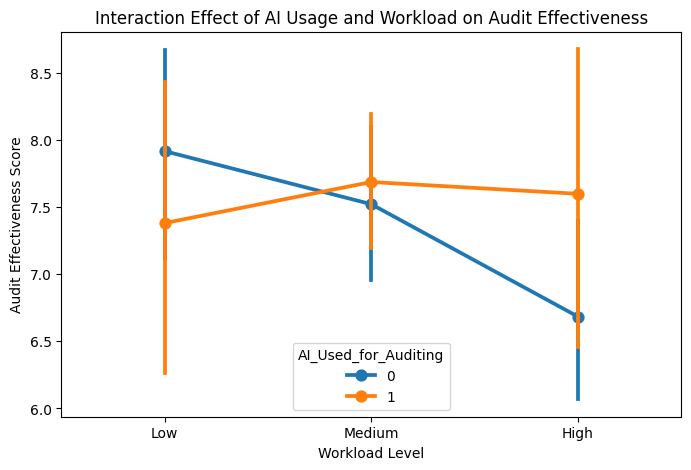

In [30]:
# Factors: AI_Used_for_Auditing (Yes/No) and Employee_Workload (Low, Medium, High)
# Response Variable: Audit_Effectiveness_Score

df_fact = df[['AI_Used_for_Auditing', 'Employee_Workload', 'Audit_Effectiveness_Score']].copy()
df_fact['AI_Used_for_Auditing'] = df_fact['AI_Used_for_Auditing'].map({'Yes': 1, 'No': 0})
df_fact['Employee_Workload'] = pd.cut(df_fact['Employee_Workload'], bins=[0, 50, 70, 100], labels=['Low', 'Medium', 'High'])

# Interaction Plot (Factorial Design) - AI vs. Workload vs. Audit Score
plt.figure(figsize=(8,5))
sns.pointplot(data=df_fact, x='Employee_Workload', y='Audit_Effectiveness_Score', hue='AI_Used_for_Auditing')
plt.xlabel("Workload Level")
plt.ylabel("Audit Effectiveness Score")
plt.title("Interaction Effect of AI Usage and Workload on Audit Effectiveness")
plt.show()

In [31]:
# Grand Mean
grand_mean = df_fact['Audit_Effectiveness_Score'].mean()

# Means
main_AI = df_fact.groupby('AI_Used_for_Auditing')['Audit_Effectiveness_Score'].mean()
main_workload = df_fact.groupby('Employee_Workload')['Audit_Effectiveness_Score'].mean()
interaction = df_fact.groupby(['AI_Used_for_Auditing', 'Employee_Workload'])['Audit_Effectiveness_Score'].mean()

# SS Calculations
SS_total = ((df_fact['Audit_Effectiveness_Score'] - grand_mean) ** 2).sum()
SS_A = sum(df_fact.groupby('AI_Used_for_Auditing').size() * (main_AI - grand_mean) ** 2)
SS_B = sum(df_fact.groupby('Employee_Workload').size() * (main_workload - grand_mean) ** 2)
SS_AB = sum(df_fact.groupby(['AI_Used_for_Auditing', 'Employee_Workload']).size() * (interaction - grand_mean) ** 2)
SS_error = SS_total - SS_A - SS_B - SS_AB

# DF
df_A = len(main_AI) - 1
df_B = len(main_workload) - 1
df_AB = df_A * df_B
df_error = len(df_fact) - (df_A + df_B + df_AB + 1)

# MS and F
MS_A = SS_A / df_A
MS_B = SS_B / df_B
MS_AB = SS_AB / df_AB
MS_error = SS_error / df_error
F_A = MS_A / MS_error
F_B = MS_B / MS_error
F_AB = MS_AB / MS_error

<ipython-input-31-8f140807faae>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  main_workload = df_fact.groupby('Employee_Workload')['Audit_Effectiveness_Score'].mean()
<ipython-input-31-8f140807faae>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df_fact.groupby(['AI_Used_for_Auditing', 'Employee_Workload'])['Audit_Effectiveness_Score'].mean()
<ipython-input-31-8f140807faae>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

In [32]:
# F-critical values
F_crit_A = f.ppf(0.95, df_A, df_error)
F_crit_B = f.ppf(0.95, df_B, df_error)
F_crit_AB = f.ppf(0.95, df_AB, df_error)

# Decisions
hypo_A = "Rejected" if F_A > F_crit_A else "Accepted"
hypo_B = "Rejected" if F_B > F_crit_B else "Accepted"
hypo_AB = "Rejected" if F_AB > F_crit_AB else "Accepted"

# Factorial ANOVA Table
fact_table = [
    ["AI Usage", SS_A, df_A, MS_A, F_A],
    ["Workload", SS_B, df_B, MS_B, F_B],
    ["Interaction", SS_AB, df_AB, MS_AB, F_AB],
    ["Error", SS_error, df_error, MS_error, ""],
    ["Total", SS_total, df_A + df_B + df_AB + df_error, "", ""]
]

print(tabulate(fact_table, headers=["Source", "SS", "DF", "MS", "F"], tablefmt="pretty", floatfmt=".4f"))

print(f"\nF-statistic (AI Usage): {F_A:.4f}, F-critical: {F_crit_A:.4f} → {hypo_A} H₀ (AI effect)")
print(f"F-statistic (Workload): {F_B:.4f}, F-critical: {F_crit_B:.4f} → {hypo_B} H₀ (Workload effect)")
print(f"F-statistic (Interaction): {F_AB:.4f}, F-critical: {F_crit_AB:.4f} → {hypo_AB} H₀ (Interaction effect)")

+-------------+--------------------+----+--------------------+--------------------+
|   Source    |         SS         | DF |         MS         |         F          |
+-------------+--------------------+----+--------------------+--------------------+
|  AI Usage   | 0.9116161616161629 | 1  | 0.9116161616161629 | 0.408648139499395  |
|  Workload   | 5.282532467532452  | 2  | 2.641266233766226  | 1.1839945119419717 |
| Interaction | 11.699756101962546 | 2  | 5.849878050981273  | 2.6223117606798034 |
|    Error    | 209.69609526888883 | 94 | 2.2308095241371153 |                    |
|    Total    |       227.59       | 99 |                    |                    |
+-------------+--------------------+----+--------------------+--------------------+

F-statistic (AI Usage): 0.4086, F-critical: 3.9423 → Accepted H₀ (AI effect)
F-statistic (Workload): 1.1840, F-critical: 3.0933 → Accepted H₀ (Workload effect)
F-statistic (Interaction): 2.6223, F-critical: 3.0933 → Accepted H₀ (Interaction ef